# Eksplorasi Analisis & Prediksi Harga Pangan Menggunakan K-Nearest Neighbors (KNN)
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi menggunakan **K-Nearest Neighbors (KNN) Regressor** untuk data harga pangan nasional berdasarkan dataset strategis dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Loading & Cleaning**: Membaca dataset dari file JSON lokal (`dataset/commodity_history.json`), mengekstrak 10 komoditas utama (level 1), dan mengubah bentuk data lebar (*wide format*) menjadi bentuk panjang (*long/tidy format*).
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual (tren harga harian) dan statistik deskriptif, serta melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test**.
3. **Data Preprocessing & Feature Engineering**: Imputasi linear, re-sampling daily harian, dan pembuatan fitur lag & rolling statistics serta fitur kalender.
4. **Feature Scaling & Feature Selection**: Menerapkan standarisasi skala menggunakan `StandardScaler` dan menganalisis dampak fitur kalender yang bising (*noisy calendar features*) pada algoritma berbasis jarak seperti KNN.
5. **Model Tuning & Training**: Melatih model `KNeighborsRegressor` dengan mencari nilai tetangga $K$ optimal.
6. **Model Evaluation & Comparison**: Mengevaluasi hasil prediksi menggunakan metrik (MAE, RMSE, MAPE, R2) dan membandingkannya dengan model **Random Forest Baseline**.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting & Loading
Kami membaca data histori dari file lokal `dataset/commodity_history.json` yang berisi rekaman harga harian untuk 10 kategori bahan pokok berikut:
- Beras
- Daging Ayam
- Daging Sapi
- Telur Ayam
- Bawang Merah
- Bawang Putih
- Cabai Merah
- Cabai Rawit
- Minyak Goreng
- Gula Pasir

Rentang waktu yang digunakan mencakup data histori dari awal tahun 2024 hingga Mei 2026.

In [38]:
print("Membaca data dari dataset/commodity_history.json...")
json_path = "dataset/commodity_history.json"
with open(json_path, 'r') as f:
    data = json.load(f)

# Mempersiapkan DataFrame mentah
df_raw = pd.DataFrame(data['data'])
# Memfilter hanya kategori utama (level 1)
df_raw = df_raw[df_raw['level'] == 1].copy()

# Menambahkan kolom Category dan Subcategory agar konsisten dengan template sebelumnya
df_raw['Category'] = df_raw['name']
df_raw['Subcategory'] = df_raw['name']

print(f"Dimensi data mentah level 1: {df_raw.shape}")
df_raw.head()

Membaca data dari dataset/commodity_history.json...
Dimensi data mentah level 1: (10, 880)


,no,name,level,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,...,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026,Category,Subcategory
0,I,Beras,1,"14,550","14,700","14,700","14,750","14,750","14,750","14,750",...,"15,650","16,000","16,000","16,000","16,000","16,000","15,650","15,650",Beras,Beras
7,II,Daging Ayam,1,"36,950","37,550","37,650","37,650","37,650","37,650","37,650",...,"40,950","38,650","38,550","38,400","38,600","38,500","40,950","40,950",Daging Ayam,Daging Ayam
9,III,Daging Sapi,1,"134,600","134,650","134,700","134,650","134,650","134,650","134,650",...,"138,350","144,400","144,400","144,550","144,700","144,800","138,350","138,350",Daging Sapi,Daging Sapi
12,IV,Telur Ayam,1,"28,850","29,350","29,250","29,200","29,150","29,150","29,150",...,"30,300","30,600","30,550","30,500","30,550","30,500","30,300","30,300",Telur Ayam,Telur Ayam
14,V,Bawang Merah,1,"40,000","41,250","41,600","42,000","42,050","42,050","42,050",...,"46,300","47,500","47,650","47,950","48,100","48,350","46,300","46,300",Bawang Merah,Bawang Merah


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (*wide format*) menjadi format panjang (*long format/tidy data*) agar siap dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari 10 komoditas pangan untuk melihat pergerakannya secara keseluruhan.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk komoditas utama (Beras).

In [39]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:  # Menandakan kolom tanggal (format DD/MM/YYYY)
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Kategori:")
print(df_tidy.groupby("Category")["Price"].describe())

Dimensi data bersih: (8750, 4)

Statistik Deskriptif Kategori:
               count           mean           std       min       25%  \
Category                                                                
Bawang Merah   875.0   42836.000000   6673.455392   27750.0   39200.0   
Bawang Putih   875.0   42382.742857   2481.026264   38500.0   40400.0   
Beras          875.0   15525.028571    310.083908   14550.0   15300.0   
Cabai Merah    875.0   51370.571429   8747.132561   30950.0   46300.0   
Cabai Rawit    875.0   57478.742857  10254.213546   38800.0   50000.0   
Daging Ayam    875.0   37896.628571   2078.990072   34350.0   36150.0   
Daging Sapi    875.0  137122.514286   2770.477424  132050.0  135300.0   
Gula Pasir     875.0   18794.800000    432.032396   17700.0   18500.0   
Minyak Goreng  875.0   20389.542857   1032.593443   18700.0   19200.0   
Telur Ayam     875.0   30751.028571   1159.190751   28450.0   29850.0   

                    50%       75%       max  
Category      

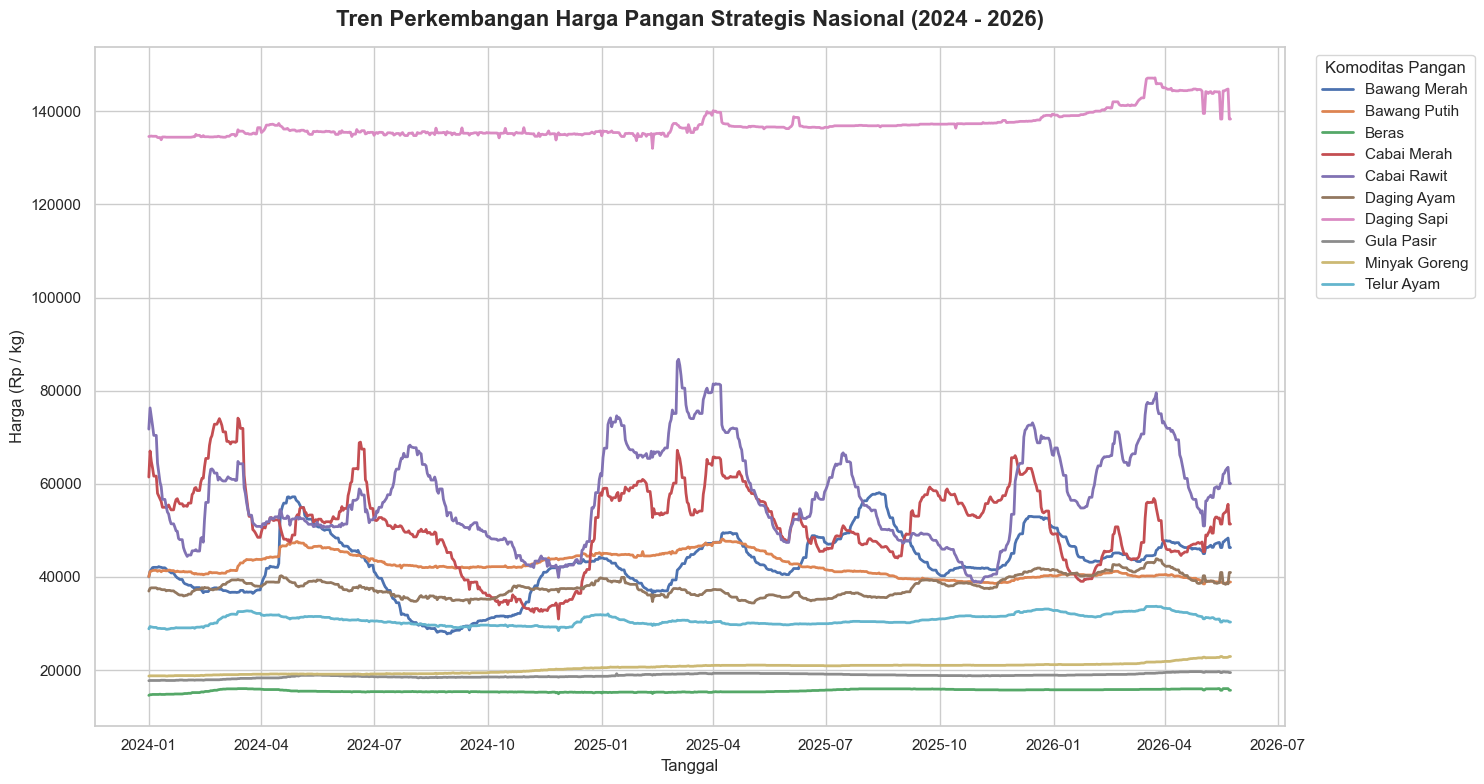

In [40]:
# Visualisasi tren harga 10 komoditas pangan harian
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_tidy, x="Date", y="Price", hue="Category", linewidth=2)
plt.title("Tren Perkembangan Harga Pangan Strategis Nasional (2024 - 2026)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga (Rp / kg)", fontsize=12)
plt.legend(title="Komoditas Pangan", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
# Menganalisis komoditas Beras
df_beras = df_tidy[df_tidy["Category"] == "Beras"].copy().set_index("Date")

# Melakukan Augmented Dickey-Fuller (ADF) Test
print("Melakukan ADF Test pada komoditas Beras:")
result = adfuller(df_beras["Price"])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.4f}")

if result[1] <= 0.05:
    print("\nKesimpulan: Data stasioner (Tolak H0)")
else:
    print("\nKesimpulan: Data tidak stasioner (Gagal menolak H0)")

Melakukan ADF Test pada komoditas Beras:
ADF Statistic: -3.5817
p-value: 0.0061
Critical Values:
	1%: -3.4380
	5%: -2.8649
	10%: -2.5686

Kesimpulan: Data stasioner (Tolak H0)


## 3. Data Preprocessing & Feature Engineering
Langkah-langkah preprocessing yang diimplementasikan:
1. **Resampling**: Memastikan frekuensi data harian konsisten ('D').
2. **Imputasi**: Mengisi data yang kosong via interpolasi linier.
3. **Calendar Features**: Mengekstrak `day_of_week`, `day_of_month`, `day_of_year`, `month`, `year`, dan `is_weekend`.
4. **Lag Features**: Membuat lag 1 hari (`lag_1`), lag 2 hari (`lag_2`), dan lag 7 hari (`lag_7`).
5. **Rolling Features**: Menggunakan rata-rata bergerak (`rolling_mean_7`) dan standar deviasi bergerak (`rolling_std_7`) 7 harian berbasis `lag_1` (untuk menghindari kebocoran data / *data leakage*).

In [42]:
def preprocess_series(df_series):
    df = df_series.copy()
    # Menyamakan frekuensi menjadi harian ('D')
    df = df.asfreq('D')
    # Mengisi kekosongan data dengan interpolasi linier
    df["Price"] = df["Price"].interpolate(method='linear').ffill().bfill()

    # Fitur Kalender
    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["day_of_year"] = df.index.dayofyear
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

    # Fitur Lag (Original - Optimal untuk menjaga dimensi tetap rendah)
    df["lag_1"] = df["Price"].shift(1)
    df["lag_2"] = df["Price"].shift(2)
    df["lag_7"] = df["Price"].shift(7)

    # Fitur Rolling (berdasarkan lag_1 untuk mencegah leakage)
    df["rolling_mean_7"] = df["lag_1"].rolling(window=7).mean()
    df["rolling_std_7"] = df["lag_1"].rolling(window=7).std()

    df = df.dropna()
    return df

df_prep = preprocess_series(df_beras)
print("Dimensi data setelah preprocessing:", df_prep.shape)
df_prep.head()

Dimensi data setelah preprocessing: (868, 14)


,Category,Subcategory,Price,day_of_week,day_of_month,day_of_year,month,year,is_weekend,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,,,
2024-01-08,Beras,Beras,14750.0,0,8,8,1,2024,0,14750.0,14750.0,14550.0,14707.142857,73.192505
2024-01-09,Beras,Beras,14750.0,1,9,9,1,2024,0,14750.0,14750.0,14700.0,14735.714286,24.397502
2024-01-10,Beras,Beras,14800.0,2,10,10,1,2024,0,14750.0,14750.0,14700.0,14742.857143,18.898224
2024-01-11,Beras,Beras,14750.0,3,11,11,1,2024,0,14800.0,14750.0,14750.0,14757.142857,18.898224
2024-01-12,Beras,Beras,14750.0,4,12,12,1,2024,0,14750.0,14800.0,14750.0,14757.142857,18.898224


In [43]:
# Pembagian data secara temporal (80% Train, 20% Test)
split_idx = int(len(df_prep) * 0.8)

df_train = df_prep.iloc[:split_idx].copy()
df_test = df_prep.iloc[split_idx:].copy()

print(f"Data Latih (Train): {df_train.index.min()} s/d {df_train.index.max()} ({len(df_train)} sampel)")
print(f"Data Uji (Test):   {df_test.index.min()} s/d {df_test.index.max()} ({len(df_test)} sampel)")

Data Latih (Train): 2024-01-08 00:00:00 s/d 2025-12-01 00:00:00 (694 sampel)
Data Uji (Test):   2025-12-02 00:00:00 s/d 2026-05-24 00:00:00 (174 sampel)


## 4. Feature Selection & Scaling (Analisis Efek Kalender Pada KNN)
Model K-Nearest Neighbors (KNN) didasarkan pada jarak geometris (seperti jarak *Euclidean*). Oleh karena itu:
1. **Fitur wajib diskalakan** (Standardisasi) agar fitur berjarak besar (seperti nilai `lag_1` sekitar Rp 15.000) tidak menenggelamkan fitur bernilai kecil (seperti `month` bernilai 1-12).
2. **Masalah Fitur Kalender yang Bising**: Pada prediksi deret waktu yang sangat kontinu seperti harga pangan, fitur kalender yang fluktuatif (`day_of_month`, `day_of_year`, `day_of_week`) seringkali menambahkan bising (*noise*) pada kalkulasi jarak tetangga KNN, sehingga menurunkan performa model. 

Kita akan menguji dan membuktikan hipotesis ini dengan melatih dua variasi model KNN:
- **KNN All Features (Scaled)**: Menggunakan semua fitur (termasuk fitur kalender).
- **KNN Optimized / Lag-Only (Scaled)**: Hanya menggunakan fitur lag harga dan rolling statistics (tanpa fitur kalender bising).

In [44]:
# Definisi daftar fitur lengkap dan fitur optimal (lag & rolling)
all_features = ["day_of_week", "day_of_month", "day_of_year", "month", "is_weekend",
                "lag_1", "lag_2", "lag_7", "rolling_mean_7", "rolling_std_7"]

optimized_features = ["lag_1", "lag_2", "lag_7", "rolling_mean_7", "rolling_std_7"]

# Pembagian Fitur dan Target
y_train = df_train["Price"]
y_test = df_test["Price"]

# 1. Scaling untuk semua fitur
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(df_train[all_features])
X_test_all_scaled = scaler_all.transform(df_test[all_features])

# 2. Scaling untuk fitur optimal (lag & rolling saja)
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(df_train[optimized_features])
X_test_opt_scaled = scaler_opt.transform(df_test[optimized_features])

print("Penskalaan fitur selesai.")

Penskalaan fitur selesai.


## 5. Hyperparameter Tuning & Model Training
Kita akan menggunakan **GridSearchCV** dikombinasikan dengan **TimeSeriesSplit** (5-fold) khusus deret waktu untuk mencari kombinasi hyperparameter terbaik bagi KNN Optimal. Parameter yang akan dituning:
- Jumlah tetangga terdekat $K$ (`n_neighbors` dari 1 s/d 20)
- Skema bobot (`weights`: 'uniform' atau 'distance')
- Metrik jarak (`metric`: 'euclidean', 'manhattan', 'minkowski')

Kombinasi Hyperparameter Terbaik Hasil GridSearchCV:
  - metric: manhattan
  - n_neighbors: 12
  - weights: uniform
R2 Score Rata-rata CV: -0.1024


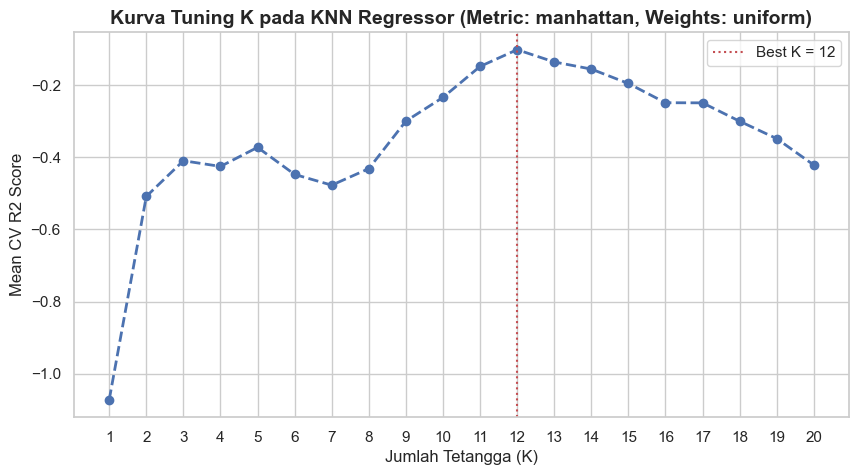

In [45]:
# Tuning hyperparameter KNN menggunakan GridSearchCV + TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_base = KNeighborsRegressor()
grid_search = GridSearchCV(knn_base, param_grid, cv=tscv, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_opt_scaled, y_train)

best_params = grid_search.best_params_
best_r2_cv = grid_search.best_score_

print("Kombinasi Hyperparameter Terbaik Hasil GridSearchCV:")
for param, val in best_params.items():
    print(f"  - {param}: {val}")
print(f"R2 Score Rata-rata CV: {best_r2_cv:.4f}")

# Ekstraksi hasil untuk visualisasi kurva K pada parameter terbaik
results = pd.DataFrame(grid_search.cv_results_)
best_metric = best_params['metric']
best_weight = best_params['weights']
filtered_results = results[(results['param_metric'] == best_metric) & (results['param_weights'] == best_weight)]
filtered_results = filtered_results.sort_values(by='param_n_neighbors')

k_values = filtered_results['param_n_neighbors'].tolist()
cv_scores = filtered_results['mean_test_score'].tolist()

# Plot Kurva Tuning K terbaik berdasarkan cross-validation
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', color='b', linestyle='--', linewidth=2)
plt.axvline(best_params['n_neighbors'], color='r', linestyle=':', label=f"Best K = {best_params['n_neighbors']}")
plt.title(f"Kurva Tuning K pada KNN Regressor (Metric: {best_metric}, Weights: {best_weight})", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Tetangga (K)", fontsize=12)
plt.ylabel("Mean CV R2 Score", fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.show()

In [46]:
# 1. Melatih Model KNN All Features (Scaled, menggunakan parameter default K=5)
knn_all = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn_all.fit(X_train_all_scaled, y_train)
df_test["knn_all_pred"] = knn_all.predict(X_test_all_scaled)

# 2. Melatih Model KNN Optimized dengan Hyperparameter Hasil GridSearchCV
knn_opt = grid_search.best_estimator_
knn_opt.fit(X_train_opt_scaled, y_train)
df_test["knn_opt_pred"] = knn_opt.predict(X_test_opt_scaled)

# 3. Melatih Model Random Forest Baseline (Unscaled, All Features) untuk pembanding tambahan
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_baseline.fit(df_train[all_features], y_train)
df_test["rf_baseline_pred"] = rf_baseline.predict(df_test[all_features])

print("Pelatihan seluruh model selesai.")

Pelatihan seluruh model selesai.


## 6. Model Evaluation
Kami membandingkan kinerja ketiga pendekatan pemodelan:
1. **KNN All Features (Scaled)** (Memasukkan noise fitur kalender)
2. **KNN Optimized (Scaled)** (Hanya lag harga & rolling statistics - Tanpa fitur kalender bising)
3. **Random Forest Baseline** (Pembanding baseline)

Metrik evaluasi:
- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Percentage Error (MAPE %)**
- **R² Score** (Koefisien Determinasi)

In [47]:
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2 Score": r2}

metrics_knn_all = evaluate_predictions(y_test, df_test["knn_all_pred"])
metrics_knn_opt = evaluate_predictions(y_test, df_test["knn_opt_pred"])
metrics_rf = evaluate_predictions(y_test, df_test["rf_baseline_pred"])

df_metrics = pd.DataFrame({
    "KNN All Features (Scaled)": metrics_knn_all,
    "KNN Optimized (Scaled)": metrics_knn_opt,
    "Random Forest Baseline": metrics_rf
}).T

print("Tabel Evaluasi Kinerja Model:")
df_metrics.round(4)

Tabel Evaluasi Kinerja Model:


,MAE,RMSE,MAPE (%),R2 Score
KNN All Features (Scaled),62.4330,80.2530,0.3950,0.1744
KNN Optimized (Scaled),25.9818,55.6952,0.1642,0.6024
Random Forest Baseline,27.7205,58.7258,0.1755,0.5579


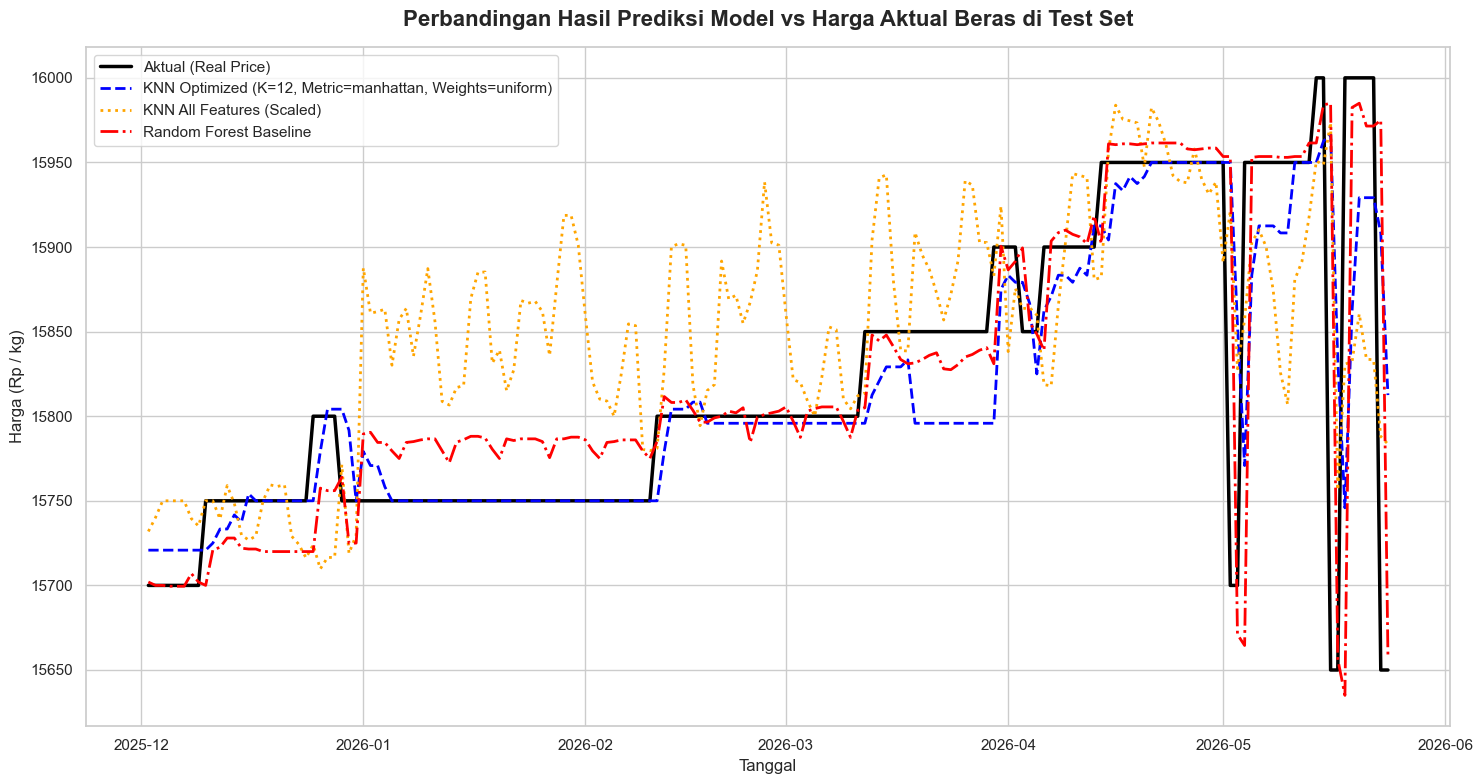

In [48]:
# Visualisasi Grafik Perbandingan Aktual vs Prediksi Model
plt.figure(figsize=(15, 8))
plt.plot(df_test.index, df_test["Price"], label="Aktual (Real Price)", color="black", linewidth=2.5)
plt.plot(df_test.index, df_test["knn_opt_pred"], label=f"KNN Optimized (K={best_params['n_neighbors']}, Metric={best_params['metric']}, Weights={best_params['weights']})", color="blue", linestyle="--", linewidth=2)
plt.plot(df_test.index, df_test["knn_all_pred"], label="KNN All Features (Scaled)", color="orange", linestyle=":", linewidth=2)
plt.plot(df_test.index, df_test["rf_baseline_pred"], label="Random Forest Baseline", color="red", linestyle="-.", linewidth=2)

plt.title("Perbandingan Hasil Prediksi Model vs Harga Aktual Beras di Test Set", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga (Rp / kg)", fontsize=12)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()